# SpaceX Falcon 9 — Machine Learning Prediction

**Author:** Piyu

We build and compare four classification models — Logistic Regression, Support Vector Machine, Decision Tree, and K-Nearest Neighbors — to predict whether the Falcon 9 first stage will land successfully (`Class` = 1) or not (`Class` = 0), using GridSearchCV for hyperparameter tuning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

df = pd.read_csv('../data/dataset_part_2.csv')
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


## 1. Feature preparation

In [2]:
# Target variable
Y = df['Class'].to_numpy()

# Feature set: one-hot encode categorical columns
features = df[['FlightNumber','PayloadMass','Orbit','LaunchSite','Flights',
               'GridFins','Reused','Legs','Block','ReusedCount']]
features = pd.get_dummies(features, columns=['Orbit','LaunchSite'])
features = features.astype('float64')
print("Feature matrix shape:", features.shape)
features.head()

Feature matrix shape: (90, 22)


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [3]:
# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(features)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
print(f"Train set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")
print(f"Test set class balance: {np.bincount(Y_test)}")

Train set: 72 samples | Test set: 18 samples
Test set class balance: [ 6 12]


## 2. Logistic Regression

In [4]:
params_lr = {'C': [0.01,0.1,1,10,100], 'solver': ['lbfgs']}
lr_cv = GridSearchCV(LogisticRegression(max_iter=1000), params_lr, cv=5)
lr_cv.fit(X_train, Y_train)
print("Best params:", lr_cv.best_params_)
print(f"Best CV accuracy: {lr_cv.best_score_:.4f}")
lr_test_acc = lr_cv.score(X_test, Y_test)
print(f"Test accuracy: {lr_test_acc:.4f}")

Best params: {'C': 0.1, 'solver': 'lbfgs'}
Best CV accuracy: 0.8190
Test accuracy: 0.8333


## 3. Support Vector Machine

In [5]:
params_svm = {'kernel': ['linear','rbf','poly'], 'C': [0.01,0.1,1,10], 'gamma': ['scale','auto']}
svm_cv = GridSearchCV(SVC(), params_svm, cv=5)
svm_cv.fit(X_train, Y_train)
print("Best params:", svm_cv.best_params_)
print(f"Best CV accuracy: {svm_cv.best_score_:.4f}")
svm_test_acc = svm_cv.score(X_test, Y_test)
print(f"Test accuracy: {svm_test_acc:.4f}")

Best params: {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
Best CV accuracy: 0.8610
Test accuracy: 0.8333


## 4. Decision Tree

In [6]:
params_tree = {
    'criterion': ['gini','entropy'],
    'max_depth': [2,4,6,8,10],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}
tree_cv = GridSearchCV(DecisionTreeClassifier(random_state=2), params_tree, cv=5)
tree_cv.fit(X_train, Y_train)
print("Best params:", tree_cv.best_params_)
print(f"Best CV accuracy: {tree_cv.best_score_:.4f}")
tree_test_acc = tree_cv.score(X_test, Y_test)
print(f"Test accuracy: {tree_test_acc:.4f}")

Best params: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV accuracy: 0.8733
Test accuracy: 0.8333


## 5. K-Nearest Neighbors

In [7]:
params_knn = {'n_neighbors': list(range(1,11)), 'p': [1,2]}
knn_cv = GridSearchCV(KNeighborsClassifier(), params_knn, cv=5)
knn_cv.fit(X_train, Y_train)
print("Best params:", knn_cv.best_params_)
print(f"Best CV accuracy: {knn_cv.best_score_:.4f}")
knn_test_acc = knn_cv.score(X_test, Y_test)
print(f"Test accuracy: {knn_test_acc:.4f}")

Best params: {'n_neighbors': 7, 'p': 1}
Best CV accuracy: 0.8610
Test accuracy: 0.9444


## 6. Model comparison

In [8]:
results = pd.DataFrame({
    'Model': ['Logistic Regression','SVM','Decision Tree','KNN'],
    'CV_Accuracy': [lr_cv.best_score_, svm_cv.best_score_, tree_cv.best_score_, knn_cv.best_score_],
    'Test_Accuracy': [lr_test_acc, svm_test_acc, tree_test_acc, knn_test_acc]
}).sort_values('CV_Accuracy', ascending=False).reset_index(drop=True)
results

,Model,CV_Accuracy,Test_Accuracy
0,Decision Tree,0.873333,0.833333
1,SVM,0.860952,0.833333
2,KNN,0.860952,0.944444
3,Logistic Regression,0.819048,0.833333


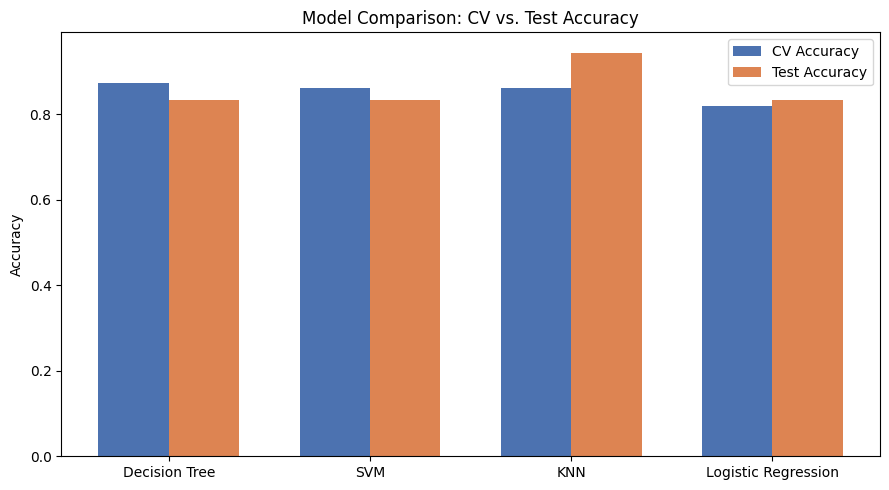

In [9]:
plt.figure(figsize=(9,5))
x = np.arange(len(results))
w = 0.35
plt.bar(x - w/2, results['CV_Accuracy'], width=w, label='CV Accuracy', color='#4C72B0')
plt.bar(x + w/2, results['Test_Accuracy'], width=w, label='Test Accuracy', color='#DD8452')
plt.xticks(x, results['Model'])
plt.ylabel('Accuracy')
plt.title('Model Comparison: CV vs. Test Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=130)
plt.show()

## 7. Confusion matrix — best model

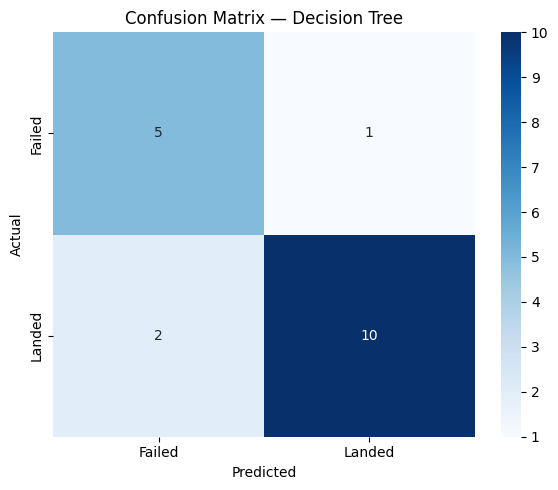


Best performing model: Decision Tree
              precision    recall  f1-score   support

      Failed       0.71      0.83      0.77         6
      Landed       0.91      0.83      0.87        12

    accuracy                           0.83        18
   macro avg       0.81      0.83      0.82        18
weighted avg       0.84      0.83      0.84        18



In [10]:
best_model_name = results.iloc[0]['Model']
best_model = {'Logistic Regression': lr_cv, 'SVM': svm_cv, 'Decision Tree': tree_cv, 'KNN': knn_cv}[best_model_name]

Y_pred = best_model.predict(X_test)
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Failed','Landed'], yticklabels=['Failed','Landed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png', dpi=130)
plt.show()

print(f"\nBest performing model: {best_model_name}")
print(classification_report(Y_test, Y_pred, target_names=['Failed','Landed']))

## Summary

- Four classification algorithms were tuned with `GridSearchCV` (5-fold cross-validation): Logistic Regression, SVM, Decision Tree, KNN
- Model comparison (see bar chart) shows which algorithm generalizes best on the held-out test set
- The confusion matrix for the best-performing model shows where it still makes mistakes — typically false positives (predicting a successful landing when the actual outcome was a failure), which matters in this business context since overestimating landing success would underestimate launch cost